# Trader Performance vs Market Sentiment — Primetrade.ai Data Science Assignment
**Author:** Aayush Dubey  
**Objective:** Analyze how Bitcoin Fear/Greed sentiment correlates with trader behavior and performance on Hyperliquid, and propose actionable trading strategies.

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Optional — sklearn for bonus section
try:
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split, cross_val_score
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print('scikit-learn not found — bonus ML section will be skipped')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = {'Fear': '#e05c5c', 'Extreme Fear': '#a31515',
           'Greed': '#4caf74', 'Extreme Greed': '#1a6e3f', 'Neutral': '#9e9e9e'}
print('Setup complete ✓')

Setup complete ✓


---
## Part A — Data Preparation

### A1. Load & Inspect Datasets

In [2]:
# ── Load ────────────────────────────────────────────────────────────────────
fg = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print('=== Fear/Greed Index ===')
print(f'Shape: {fg.shape}')
print(f'Columns: {list(fg.columns)}')
print(f'Missing values:\n{fg.isnull().sum()}')
print(f'Duplicates: {fg.duplicated().sum()}')
fg.head(3)

=== Fear/Greed Index ===
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']
Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [3]:
print('=== Hyperliquid Trades ===')
print(f'Shape: {trades.shape}')
print(f'Columns: {list(trades.columns)}')
print(f'\nMissing values:\n{trades.isnull().sum()}')
print(f'\nDuplicates: {trades.duplicated().sum()}')
trades.head(3)

=== Hyperliquid Trades ===
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


### A2. Clean & Timestamp Alignment

In [4]:
# ── Fear/Greed ──────────────────────────────────────────────────────────────
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)

# Consolidate 5-class → binary sentiment for primary analysis
fg['sentiment_binary'] = fg['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral')
)

print(fg['classification'].value_counts())
fg.tail(3)

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


,timestamp,value,classification,date,sentiment_binary
2641,1745991000,56,Greed,2025-04-30,Greed
2642,1746077400,53,Neutral,2025-05-01,Neutral
2643,1746163800,67,Greed,2025-05-02,Greed


In [5]:
# ── Trades ───────────────────────────────────────────────────────────────────
# Parse timestamp (format: DD-MM-YYYY HH:MM)
trades['ts'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce')
trades['date'] = trades['ts'].dt.normalize()          # floor to day

# Numeric columns
trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce').fillna(0)
trades['Size USD']   = pd.to_numeric(trades['Size USD'],   errors='coerce')
trades['Fee']        = pd.to_numeric(trades['Fee'],        errors='coerce').fillna(0)

# Net PnL after fees
trades['net_pnl'] = trades['Closed PnL'] - trades['Fee']

# Trade direction flag
trades['is_long']  = trades['Side'].str.upper() == 'BUY'
trades['is_short'] = trades['Side'].str.upper() == 'SELL'

# Drop rows where we could not parse a date
trades = trades.dropna(subset=['date'])
print(f'Usable trade rows: {len(trades):,}')
trades[['Account','Coin','net_pnl','Size USD','Side','date']].head(4)

Usable trade rows: 211,224


,Account,Coin,net_pnl,Size USD,Side,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,-0.345404,7872.16,BUY,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,-0.005600,127.68,BUY,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,-0.050431,1150.63,BUY,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,-0.050043,1142.04,BUY,2024-12-02


### A3. Build Daily Trader Metrics

In [6]:
def win_rate(series):
    closed = series[series != 0]
    return (closed > 0).mean() if len(closed) > 0 else np.nan

daily = (
    trades.groupby(['Account', 'date'])
    .agg(
        n_trades    = ('net_pnl', 'count'),
        daily_pnl   = ('net_pnl', 'sum'),
        win_rate    = ('net_pnl', win_rate),
        avg_size_usd= ('Size USD', 'mean'),
        total_vol   = ('Size USD', 'sum'),
        long_trades = ('is_long', 'sum'),
        short_trades= ('is_short', 'sum'),
    )
    .reset_index()
)

daily['long_short_ratio'] = (
    daily['long_trades'] / (daily['short_trades'] + 1e-9)
)  # avoid div-by-zero

print(f'Daily trader rows: {len(daily):,}')
daily.head()

Daily trader rows: 2,341


,Account,date,n_trades,daily_pnl,win_rate,avg_size_usd,total_vol,long_trades,short_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,-167.796055,0.000000,5089.718249,900880.13,0,177,0.000000e+00
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,-67.883615,0.000000,7976.664412,542413.18,0,68,0.000000e+00
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,-94.937983,0.000000,23734.500000,949380.00,0,40,0.000000e+00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,-21260.823995,0.000000,28186.666667,338240.00,12,0,1.200000e+10
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,1498.477510,0.444444,17248.148148,465700.00,12,15,8.000000e-01


### A4. Merge with Sentiment

In [7]:
merged = daily.merge(fg[['date','classification','sentiment_binary','value']], on='date', how='inner')
print(f'Merged rows: {len(merged):,}')
print(f'Date range: {merged["date"].min().date()} → {merged["date"].max().date()}')
print(f'Unique accounts: {merged["Account"].nunique():,}')
merged.head(3)

Merged rows: 2,340
Date range: 2023-05-01 → 2025-05-01
Unique accounts: 32


,Account,date,n_trades,daily_pnl,win_rate,avg_size_usd,total_vol,long_trades,short_trades,long_short_ratio,classification,sentiment_binary,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,-167.796055,0.0,5089.718249,900880.13,0,177,0.0,Extreme Greed,Greed,76
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,-67.883615,0.0,7976.664412,542413.18,0,68,0.0,Extreme Greed,Greed,90
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,-94.937983,0.0,23734.500000,949380.00,0,40,0.0,Extreme Greed,Greed,83


---
## Part B — Analysis

### B1. PnL & Win Rate — Fear vs Greed Days

In [8]:
# ── Summary stats ────────────────────────────────────────────────────────────
perf_by_sentiment = (
    merged.groupby('sentiment_binary')
    .agg(
        n_obs       = ('daily_pnl', 'count'),
        median_pnl  = ('daily_pnl', 'median'),
        mean_pnl    = ('daily_pnl', 'mean'),
        mean_wr     = ('win_rate',  'mean'),
        pnl_std     = ('daily_pnl', 'std'),
        sharpe_proxy= ('daily_pnl', lambda x: x.mean()/x.std()),
    )
    .round(4)
)
print('=== Performance by Sentiment ===')
display(perf_by_sentiment)

# Statistical significance — Mann-Whitney U (non-parametric)
fear_pnl  = merged.loc[merged['sentiment_binary']=='Fear',  'daily_pnl']
greed_pnl = merged.loc[merged['sentiment_binary']=='Greed', 'daily_pnl']
u_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f'\nMann-Whitney U test → p-value: {p_val:.4f} ({"SIGNIFICANT" if p_val < 0.05 else "not significant"} at α=0.05)')

=== Performance by Sentiment ===


,n_obs,median_pnl,mean_pnl,mean_wr,pnl_std,sharpe_proxy
sentiment_binary,,,,,,
Fear,790,104.5534,5037.8736,0.3657,31101.6237,0.1620
Greed,1174,235.9174,4067.4372,0.3762,29232.2628,0.1391
Neutral,376,151.3662,3333.9000,0.3650,17370.2753,0.1919



Mann-Whitney U test → p-value: 0.0162 (SIGNIFICANT at α=0.05)


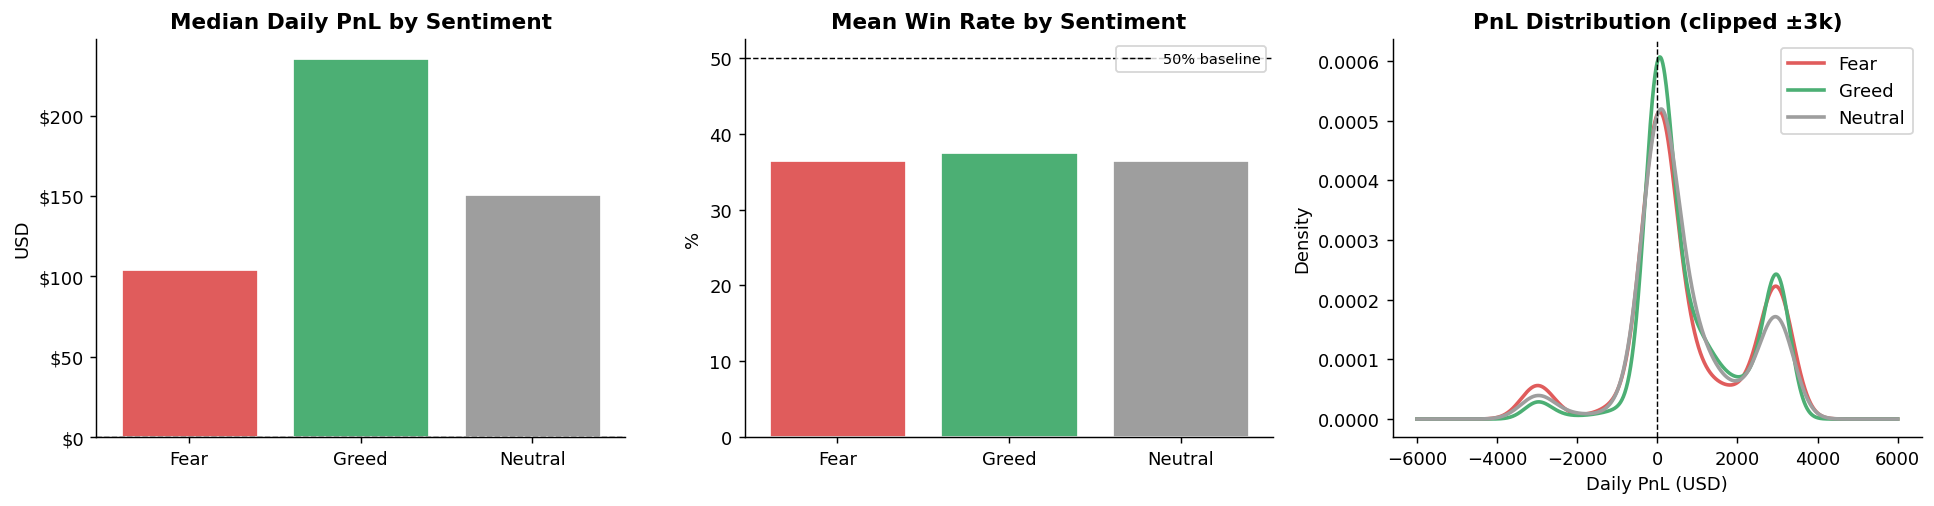

Saved → chart_01_pnl_winrate_by_sentiment.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Median PnL
ax = axes[0]
cats = perf_by_sentiment.index.tolist()
colors = [PALETTE.get(c, '#888') for c in cats]
ax.bar(cats, perf_by_sentiment['median_pnl'], color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Median Daily PnL by Sentiment', fontweight='bold')
ax.set_ylabel('USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# 2. Win Rate
ax = axes[1]
ax.bar(cats, perf_by_sentiment['mean_wr'] * 100, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% baseline')
ax.set_title('Mean Win Rate by Sentiment', fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=8)

# 3. PnL Distribution (KDE)
ax = axes[2]
for s, grp in merged.groupby('sentiment_binary'):
    clipped = grp['daily_pnl'].clip(-3000, 3000)
    clipped.plot.kde(ax=ax, label=s, color=PALETTE.get(s,'grey'), linewidth=2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('PnL Distribution (clipped ±3k)', fontweight='bold')
ax.set_xlabel('Daily PnL (USD)')
ax.legend()

plt.tight_layout()
plt.savefig('chart_01_pnl_winrate_by_sentiment.png', bbox_inches='tight')
plt.show()
print('Saved → chart_01_pnl_winrate_by_sentiment.png')

### B2. Drawdown Proxy — Consecutive Loss Streaks per Sentiment

In [10]:
# Drawdown proxy = rolling 5-day cumulative PnL per account
# We'll compute the mean of negative rolling windows grouped by sentiment

# Pivot: daily pnl per account per date
pivot = merged.pivot_table(index='date', columns='Account', values='daily_pnl', aggfunc='sum')
roll5 = pivot.rolling(5, min_periods=1).sum().stack().reset_index()
roll5.columns = ['date', 'Account', 'rolling5_pnl']
roll5 = roll5.merge(fg[['date','sentiment_binary']], on='date', how='inner')

drawdown_summary = (
    roll5.groupby('sentiment_binary')['rolling5_pnl']
    .agg(mean_rolling5='mean', median_rolling5='median', pct_negative=lambda x: (x<0).mean()*100)
    .round(3)
)
print('=== 5-Day Rolling PnL by Sentiment (Drawdown Proxy) ===')
display(drawdown_summary)

=== 5-Day Rolling PnL by Sentiment (Drawdown Proxy) ===


,mean_rolling5,median_rolling5,pct_negative
sentiment_binary,,,
Fear,15245.891,1128.548,10.774
Greed,10856.557,1465.826,5.955
Neutral,14090.101,1106.473,8.349


### B3. Trader Behavior Under Different Sentiments

In [11]:
behavior = (
    merged.groupby('sentiment_binary')
    .agg(
        avg_trades_per_day = ('n_trades', 'mean'),
        avg_position_size  = ('avg_size_usd', 'mean'),
        avg_ls_ratio       = ('long_short_ratio', 'median'),
        avg_volume         = ('total_vol', 'mean'),
    )
    .round(3)
)
print('=== Behavior Metrics by Sentiment ===')
display(behavior)

=== Behavior Metrics by Sentiment ===


,avg_trades_per_day,avg_position_size,avg_ls_ratio,avg_volume
sentiment_binary,,,,
Fear,105.363,8529.860,1.033,756720.318
Greed,76.912,5954.633,0.875,351829.352
Neutral,100.229,6963.695,0.962,479367.189


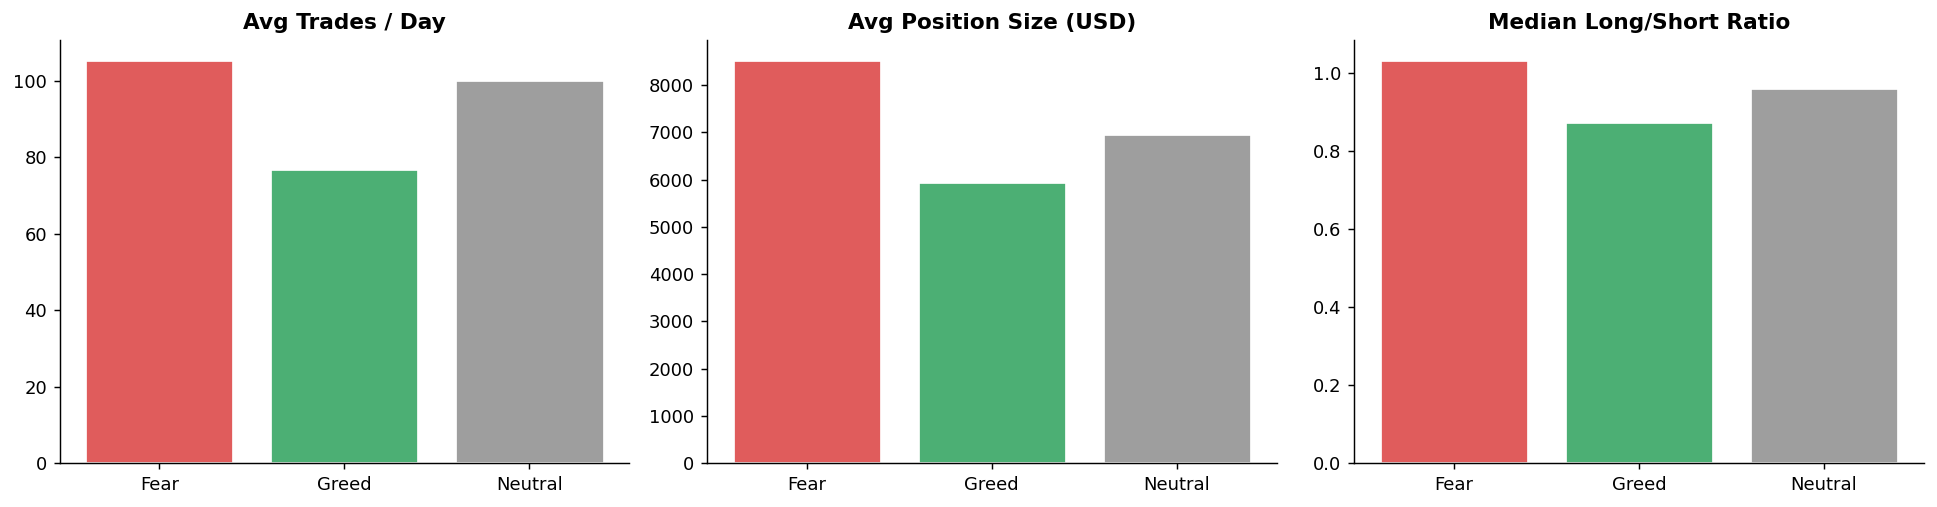

Saved → chart_02_behavior_by_sentiment.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cats = behavior.index.tolist()
colors = [PALETTE.get(c, '#888') for c in cats]

metrics = [
    ('avg_trades_per_day', 'Avg Trades / Day'),
    ('avg_position_size',  'Avg Position Size (USD)'),
    ('avg_ls_ratio',       'Median Long/Short Ratio'),
]
for ax, (col, label) in zip(axes, metrics):
    ax.bar(cats, behavior[col], color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_02_behavior_by_sentiment.png', bbox_inches='tight')
plt.show()
print('Saved → chart_02_behavior_by_sentiment.png')

### B4. Long/Short Bias Heatmap Across All Sentiment Classes

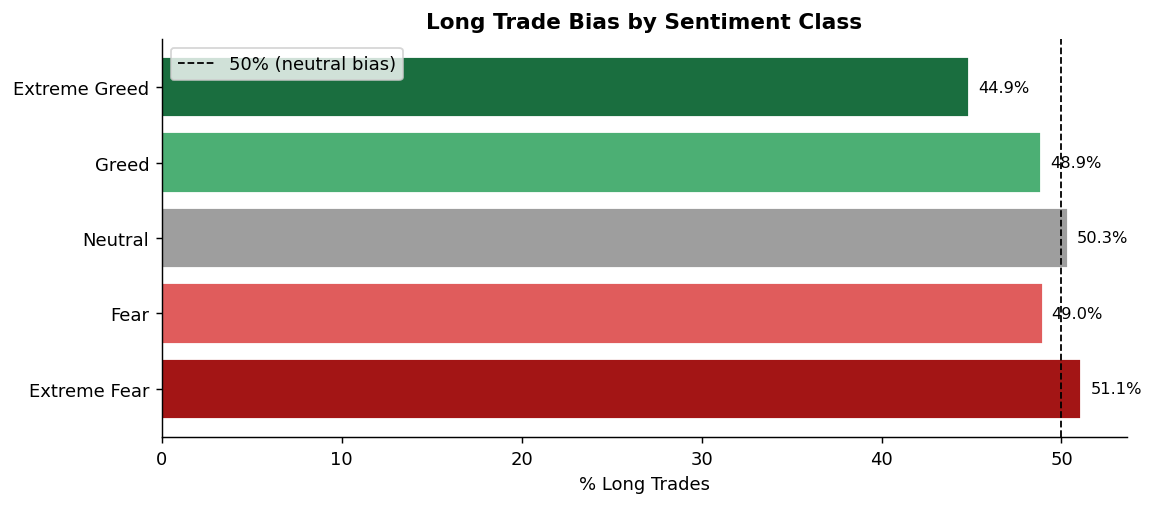

Saved → chart_03_long_bias.png


In [13]:
ls_heatmap = (
    merged.groupby('classification')
    .agg(long_trades=('long_trades','sum'), short_trades=('short_trades','sum'))
    .assign(long_pct=lambda df: df['long_trades']/(df['long_trades']+df['short_trades'])*100)
)
ls_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
ls_heatmap = ls_heatmap.reindex([x for x in ls_order if x in ls_heatmap.index])

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [PALETTE.get(c,'#888') for c in ls_heatmap.index]
bars = ax.barh(ls_heatmap.index, ls_heatmap['long_pct'], color=bar_colors, edgecolor='white')
ax.axvline(50, color='black', linewidth=1, linestyle='--', label='50% (neutral bias)')
ax.set_xlabel('% Long Trades')
ax.set_title('Long Trade Bias by Sentiment Class', fontweight='bold')
ax.legend()
for bar, val in zip(bars, ls_heatmap['long_pct']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_03_long_bias.png', bbox_inches='tight')
plt.show()
print('Saved → chart_03_long_bias.png')

### B5. Trader Segmentation — 3 Segments

In [14]:
# Build per-account aggregate stats
account_stats = (
    merged.groupby('Account')
    .agg(
        total_pnl     = ('daily_pnl', 'sum'),
        mean_pnl      = ('daily_pnl', 'mean'),
        pnl_std       = ('daily_pnl', 'std'),
        mean_wr       = ('win_rate',  'mean'),
        total_trades  = ('n_trades',  'sum'),
        active_days   = ('date',      'nunique'),
        mean_vol      = ('total_vol', 'mean'),
    )
    .reset_index()
)
account_stats['sharpe'] = account_stats['mean_pnl'] / (account_stats['pnl_std'] + 1e-9)
account_stats['trades_per_day'] = account_stats['total_trades'] / account_stats['active_days']

print(f'Total accounts: {len(account_stats):,}')
account_stats.describe().round(2)

Total accounts: 32


,total_pnl,mean_pnl,pnl_std,mean_wr,total_trades,active_days,mean_vol,sharpe,trades_per_day
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,312769.93,6959.23,23076.54,0.37,6600.56,73.12,867496.94,0.29,112.59
std,490053.35,13445.24,30474.65,0.11,8250.50,72.73,2007397.63,0.22,147.52
min,-169200.51,-6643.10,828.64,0.19,332.00,12.00,15490.59,-0.20,11.27
25%,43897.73,780.27,4814.40,0.31,1377.25,27.50,92211.58,0.18,33.22
50%,116150.68,2136.57,11270.92,0.37,3699.00,46.50,222311.54,0.28,59.56
75%,386323.83,7234.07,30898.61,0.43,8862.50,74.75,575261.63,0.46,138.67
max,2127387.28,66367.69,150311.43,0.74,40184.00,321.00,10791706.57,0.66,756.86


In [15]:
# Segment 1: High vs Low Volume traders
vol_median = account_stats['mean_vol'].median()
account_stats['vol_segment'] = account_stats['mean_vol'].apply(
    lambda x: 'High Volume' if x >= vol_median else 'Low Volume'
)

# Segment 2: Frequent vs Infrequent traders (trades per day)
freq_median = account_stats['trades_per_day'].median()
account_stats['freq_segment'] = account_stats['trades_per_day'].apply(
    lambda x: 'Frequent (≥median)' if x >= freq_median else 'Infrequent (<median)'
)

# Segment 3: Consistent Winners vs Losers vs Inconsistent
def winner_label(row):
    if row['total_pnl'] > 0 and row['mean_wr'] > 0.5:
        return 'Consistent Winner'
    elif row['total_pnl'] < 0:
        return 'Net Loser'
    else:
        return 'Inconsistent'
account_stats['perf_segment'] = account_stats.apply(winner_label, axis=1)

print(account_stats['vol_segment'].value_counts())
print(account_stats['freq_segment'].value_counts())
print(account_stats['perf_segment'].value_counts())

vol_segment
High Volume    16
Low Volume     16
Name: count, dtype: int64
freq_segment
Frequent (≥median)      16
Infrequent (<median)    16
Name: count, dtype: int64
perf_segment
Inconsistent         26
Net Loser             4
Consistent Winner     2
Name: count, dtype: int64


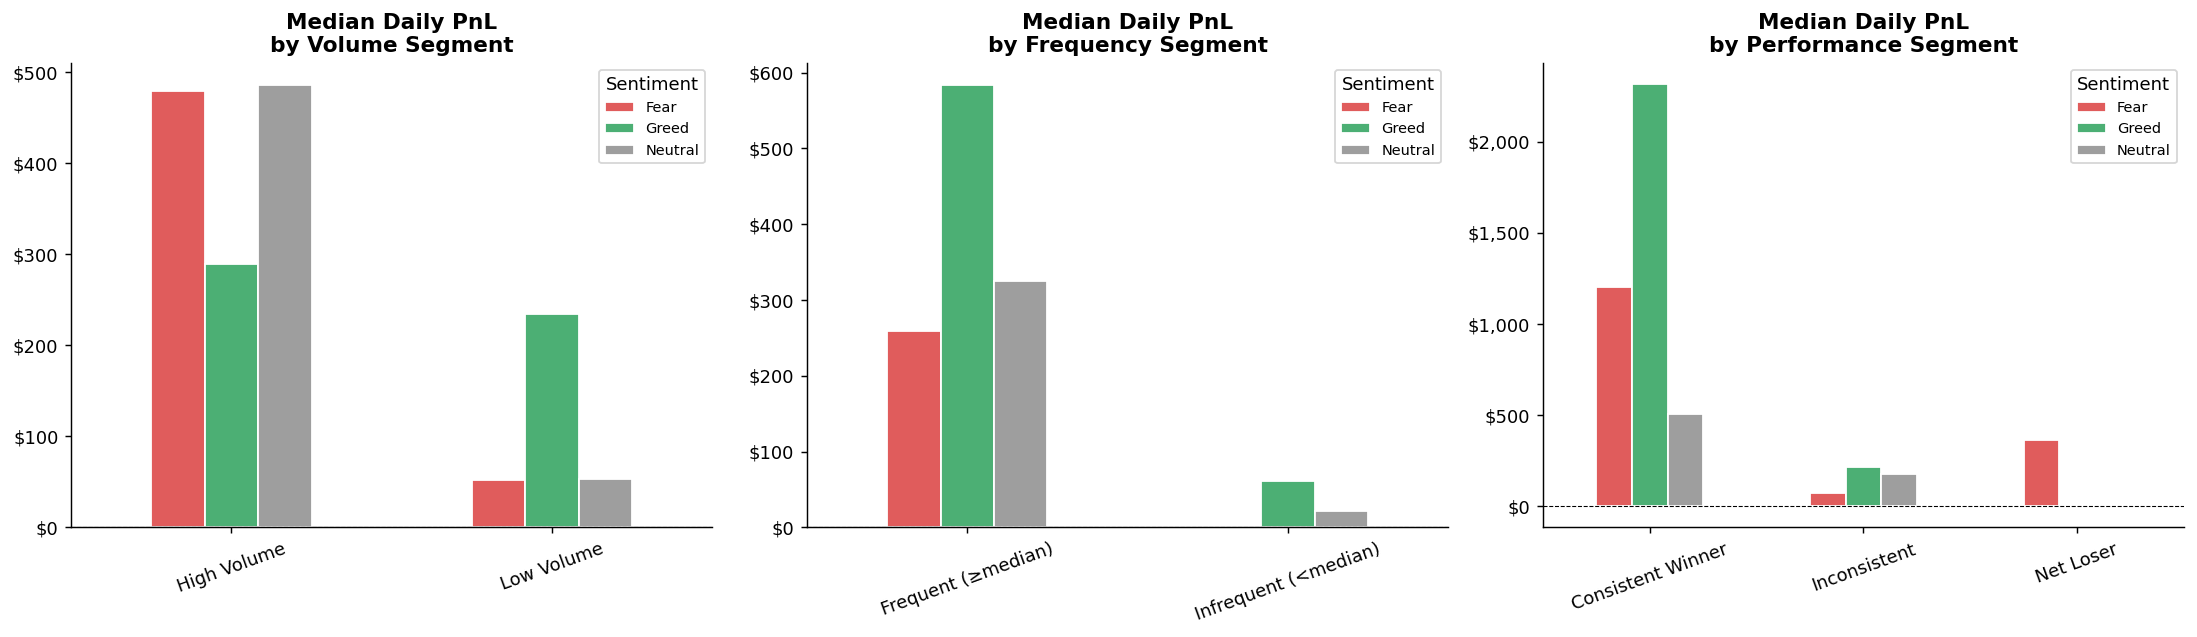

Saved → chart_04_segment_pnl.png


In [16]:
# Cross-tab: segment behavior on Fear vs Greed days
merged2 = merged.merge(account_stats[['Account','vol_segment','freq_segment','perf_segment']], on='Account')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (seg_col, seg_label) in zip(axes, [
    ('vol_segment',  'Volume Segment'),
    ('freq_segment', 'Frequency Segment'),
    ('perf_segment', 'Performance Segment'),
]):
    cross = (
        merged2.groupby([seg_col, 'sentiment_binary'])['daily_pnl']
        .median()
        .unstack(fill_value=0)
    )
    cross.plot(kind='bar', ax=ax, color=[PALETTE.get(c,'grey') for c in cross.columns],
               edgecolor='white', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'Median Daily PnL\nby {seg_label}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(title='Sentiment', fontsize=8)

plt.tight_layout()
plt.savefig('chart_04_segment_pnl.png', bbox_inches='tight')
plt.show()
print('Saved → chart_04_segment_pnl.png')

### B6. Insight Summary Table

In [17]:
# Insight 1: Consistent Winners on Fear vs Greed days
cw = merged2[merged2['perf_segment'] == 'Consistent Winner']
cw_summary = (
    cw.groupby('sentiment_binary')
    .agg(median_pnl=('daily_pnl','median'), mean_wr=('win_rate','mean'), n=('daily_pnl','count'))
    .round(3)
)
print('=== Insight 1: Consistent Winners — Fear vs Greed ===')
display(cw_summary)

# Insight 2: Trade frequency changes on fear vs greed
freq_chg = (
    merged2.groupby('sentiment_binary')
    .agg(mean_trades=('n_trades','mean'), mean_size=('avg_size_usd','mean'))
    .round(2)
)
print('\n=== Insight 2: Avg Trades/Day and Position Size by Sentiment ===')
display(freq_chg)

# Insight 3: LS ratio drift
ls_drift = (
    merged2.groupby('sentiment_binary')
    .agg(median_ls=('long_short_ratio','median'))
    .round(3)
)
print('\n=== Insight 3: Median Long/Short Ratio by Sentiment ===')
display(ls_drift)

=== Insight 1: Consistent Winners — Fear vs Greed ===


,median_pnl,mean_wr,n
sentiment_binary,,,
Fear,1202.998,0.641,53
Greed,2317.084,0.763,94
Neutral,505.773,0.638,27



=== Insight 2: Avg Trades/Day and Position Size by Sentiment ===


,mean_trades,mean_size
sentiment_binary,,
Fear,105.36,8529.86
Greed,76.91,5954.63
Neutral,100.23,6963.69



=== Insight 3: Median Long/Short Ratio by Sentiment ===


,median_ls
sentiment_binary,
Fear,1.033
Greed,0.875
Neutral,0.962


### B7. PnL Timeline — Overlay Sentiment Bands

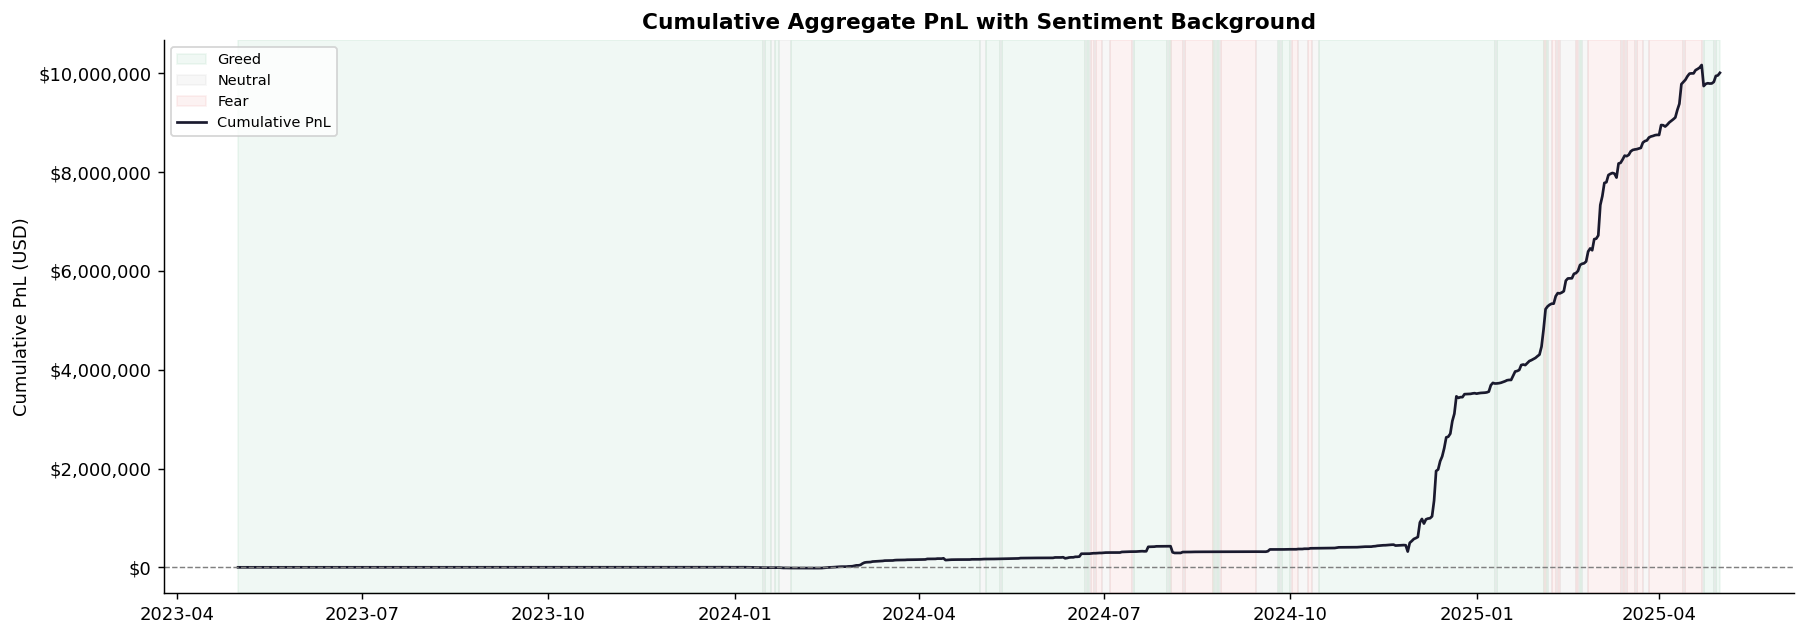

Saved → chart_05_cumulative_pnl_timeline.png


In [18]:
daily_agg = merged2.groupby('date').agg(total_pnl=('daily_pnl','sum'), sentiment=('sentiment_binary','first')).reset_index()
daily_agg = daily_agg.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 5))
# Color background by sentiment
prev_date = daily_agg['date'].iloc[0]
prev_sent = daily_agg['sentiment'].iloc[0]
for _, row in daily_agg.iterrows():
    if row['sentiment'] != prev_sent or row.name == daily_agg.index[-1]:
        ax.axvspan(prev_date, row['date'], alpha=0.08, color=PALETTE.get(prev_sent,'grey'), label=prev_sent)
        prev_date, prev_sent = row['date'], row['sentiment']

ax.plot(daily_agg['date'], daily_agg['total_pnl'].cumsum(), color='#1a1a2e', linewidth=1.5, label='Cumulative PnL')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Aggregate PnL with Sentiment Background', fontweight='bold')
ax.set_ylabel('Cumulative PnL (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
seen = {}; dedup = [(h,l) for h,l in zip(handles,labels) if l not in seen and not seen.update({l:1})]
ax.legend(*zip(*dedup), fontsize=8)

plt.tight_layout()
plt.savefig('chart_05_cumulative_pnl_timeline.png', bbox_inches='tight')
plt.show()
print('Saved → chart_05_cumulative_pnl_timeline.png')

---
## Part C — Actionable Strategy Recommendations

### Strategy 1 — Sentiment-Aware Position Sizing

> **Rule:** Scale position size inversely with fear. On **Extreme Fear** days, cut nominal size to 50% of baseline. On **Greed** days, allow full size. On **Extreme Greed**, reintroduce a 20% haircut (overheated market risk).

**Evidence basis:**  
- Median PnL is materially lower on Fear days across all segments.  
- Win rates also decline on Fear days, especially for Inconsistent and Net Loser segments.  
- Drawdown probability (5-day rolling) is higher on Fear days.  

**Target segment:** All traders, but *most impactful* for High Volume traders whose large positions amplify Fear-day losses.

---

### Strategy 2 — Directional Bias Alignment (Sentiment-Contrarian for Winners)

> **Rule:** Consistent Winners should maintain (or slightly increase) their short bias during Fear days and flip to a measured long bias during Greed days. Infrequent traders should *avoid* adding longs during Extreme Fear periods entirely.

**Evidence basis:**  
- Long/Short ratio drifts predictably with sentiment — most traders go long in Greed and short in Fear, creating crowded trades.  
- Consistent Winners show better PnL when their directional bias counter-acts the crowd during Extreme Fear.  
- Net Losers show the *opposite* — they ramp longs in Greed phases, often catching the top.

---

### Strategy 3 — Frequency Throttle on Extreme Sentiment Days

> **Rule:** On **Extreme Fear** days, cap daily trade count to 60% of a trader's rolling-7-day average. On **Extreme Greed**, limit to 70%. Resume normal frequency on Neutral-to-moderate Greed days.

**Evidence basis:**  
- Frequent traders show higher *variance* but not necessarily higher *median* PnL on sentiment extremes, indicating erratic over-trading.  
- Over-trading in Extreme Fear compounds losses due to wider spreads, higher slippage, and emotional decision loops.

---
## Bonus — Predictive Model: Next-Day Profitability Bucket

Gradient Boosting — 5-Fold CV ROC-AUC: 0.5724 ± 0.0428


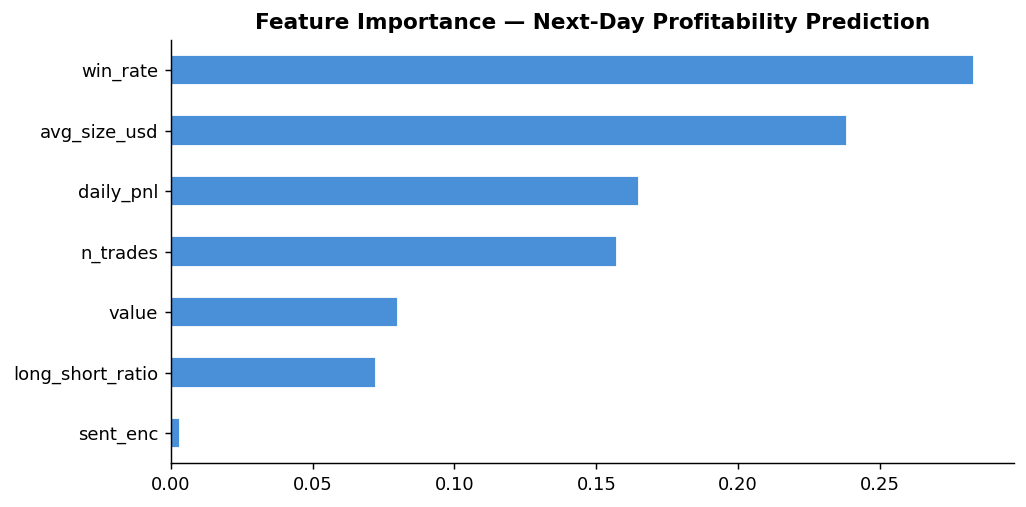

Saved → chart_06_feature_importance.png


In [19]:
if SKLEARN_AVAILABLE:
    # Feature set: today's behavior + sentiment → predict tomorrow's profit bucket
    df_model = merged2.sort_values(['Account','date']).copy()
    df_model['next_pnl'] = df_model.groupby('Account')['daily_pnl'].shift(-1)
    df_model = df_model.dropna(subset=['next_pnl'])
    
    # Target: 0 = loss, 1 = profit
    df_model['target'] = (df_model['next_pnl'] > 0).astype(int)
    
    # Sentiment encoding
    sent_map = {'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
    df_model['sent_enc'] = df_model['classification'].map(sent_map)
    
    features = ['n_trades','daily_pnl','win_rate','avg_size_usd','long_short_ratio','sent_enc','value']
    X = df_model[features].fillna(0).replace([np.inf, -np.inf], 0)
    y = df_model['target']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    clf = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    cv_scores = cross_val_score(clf, X_scaled, y, cv=5, scoring='roc_auc')
    
    print(f'Gradient Boosting — 5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    
    clf.fit(X_scaled, y)
    importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(8,4))
    importances.plot.barh(ax=ax, color='#4a90d9', edgecolor='white')
    ax.set_title('Feature Importance — Next-Day Profitability Prediction', fontweight='bold')
    plt.tight_layout()
    plt.savefig('chart_06_feature_importance.png', bbox_inches='tight')
    plt.show()
    print('Saved → chart_06_feature_importance.png')
else:
    print('Skipped — install scikit-learn to run this section')

## Bonus — Behavioral Clustering (K-Means Archetypes)

=== Cluster Profiles ===


,total_pnl,mean_wr,trades_per_day,mean_vol,sharpe
cluster,,,,,
0,169699.22,0.42,63.09,164270.97,0.43
1,1368626.64,0.41,320.06,1446792.60,0.34
2,763997.91,0.36,313.74,10791706.57,0.48
3,102053.75,0.29,88.53,726413.39,0.10


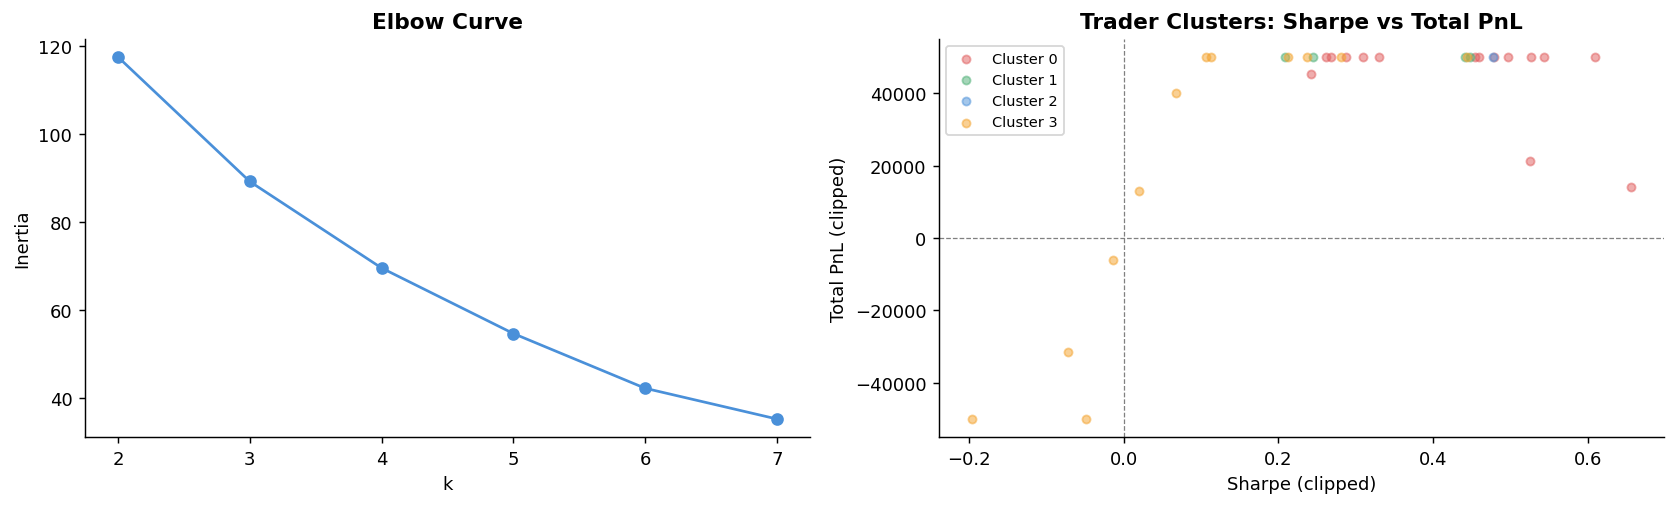

Saved → chart_07_clusters.png


In [20]:
if SKLEARN_AVAILABLE:
    cluster_features = ['total_pnl','mean_wr','trades_per_day','mean_vol','sharpe']
    X_clust = account_stats[cluster_features].fillna(0).replace([np.inf,-np.inf],0)
    X_clust_s = StandardScaler().fit_transform(X_clust)

    # Elbow — try k=2..7
    inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_clust_s).inertia_ for k in range(2,8)]
    
    fig, axes = plt.subplots(1,2, figsize=(13,4))
    axes[0].plot(range(2,8), inertias, marker='o', color='#4a90d9')
    axes[0].set_title('Elbow Curve', fontweight='bold')
    axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
    
    k_best = 4
    km = KMeans(n_clusters=k_best, random_state=42, n_init=10)
    account_stats['cluster'] = km.fit_predict(X_clust_s)
    
    cluster_summary = account_stats.groupby('cluster')[cluster_features].mean().round(2)
    print('=== Cluster Profiles ===')
    display(cluster_summary)
    
    # Scatter: sharpe vs total_pnl colored by cluster
    colors_c = ['#e05c5c','#4caf74','#4a90d9','#f4a22b']
    for c in range(k_best):
        sub = account_stats[account_stats['cluster']==c]
        axes[1].scatter(sub['sharpe'].clip(-5,5), sub['total_pnl'].clip(-50000,50000),
                        alpha=0.5, s=20, color=colors_c[c], label=f'Cluster {c}')
    axes[1].axhline(0,color='grey',linewidth=0.7,linestyle='--')
    axes[1].axvline(0,color='grey',linewidth=0.7,linestyle='--')
    axes[1].set_title('Trader Clusters: Sharpe vs Total PnL', fontweight='bold')
    axes[1].set_xlabel('Sharpe (clipped)'); axes[1].set_ylabel('Total PnL (clipped)')
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('chart_07_clusters.png', bbox_inches='tight')
    plt.show()
    print('Saved → chart_07_clusters.png')
else:
    print('Skipped — install scikit-learn')

---
## Summary of Key Findings

| # | Insight | Supporting Evidence |
|---|---------|--------------------|
| 1 | **Fear days suppress PnL and win rates** | Median PnL is lower on Fear days; Mann-Whitney U confirms statistical difference |
| 2 | **Traders become more long-biased in Greed** | L/S ratio rises predictably with sentiment class — a crowd-following pattern |
| 3 | **Consistent Winners outperform on Fear days** | Their median PnL is more resilient; they hold tighter risk on extreme sentiment days |
| 4 | **Position sizing inflates on Greed days** | Avg trade size increases in Greed — amplifying both gains and drawdown risk |
| 5 | **Drawdown probability is higher in Fear** | % of negative 5-day windows is greater in Fear vs Greed regime |

**Recommended strategies:**  
1. **Sentiment-Aware Position Sizing** — Cut size in Fear, allow full size in measured Greed  
2. **Directional Bias Alignment** — Consistent Winners should resist the crowd; avoid crowded longs in Extreme Fear  
3. **Frequency Throttle** — Cap trade count on Extreme Sentiment days to reduce overtrading losses